In [49]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import os
import gc
import random
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

In [50]:
# ==========================================
# RANDOM SEED
# ==========================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed(SEED)

    torch.cuda.manual_seed_all(SEED)

print("Seed:", SEED)

Seed: 42


In [51]:
# ==========================================
# DEVICE
# ==========================================

device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

print("Device :", device)

if torch.cuda.is_available():

    print(

        "GPU :",

        torch.cuda.get_device_name(0)

    )

Device : cuda
GPU : Tesla T4


In [52]:
# ==========================================
# MOUNT GOOGLE DRIVE
# ==========================================

from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
# ==========================================
# PROJECT DIRECTORY
# ==========================================

PROJECT_DIR = "/content/drive/MyDrive/AQI_BiLSTM_Project"

os.makedirs(PROJECT_DIR, exist_ok=True)

print("Project Folder Created")

print(PROJECT_DIR)

Project Folder Created
/content/drive/MyDrive/AQI_BiLSTM_Project


In [57]:
# ==========================================
# DATASET PATH
# ==========================================

DATA_PATH = "/content/drive/MyDrive/ML_Ready_Air_Quality_Dataset.csv"

print(DATA_PATH)

/content/drive/MyDrive/ML_Ready_Air_Quality_Dataset.csv


In [58]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(DATA_PATH)

print("="*60)
print("Dataset Loaded Successfully")
print("="*60)

print("Rows :", len(df))
print("Columns :", len(df.columns))

df.head()

Dataset Loaded Successfully
Rows : 3431900
Columns : 25


,Timestamp,PM2.5,PM10,Nitric Oxide,Nitrogen Dioxide,Nitrogen Oxides,Ammonia,Sulfur Dioxide,Carbon Monoxide,Ozone,...,City,Latitude,Longitude,Calculated_AQI,Month,Hour,DayOfWeek,Is_Weekend,State_Encoded,City_Encoded
0,2017-09-05 11:00:00,25.0,45.0,1.80,12.20,7.90,10.20,5.60,0.10,79.5,...,"Anand Kala Kshetram, Rajamahendravaram (, )",16.987287,81.736318,90.105556,9,11,1,0,0,3
1,2017-09-05 12:00:00,25.0,45.0,1.80,12.20,7.90,10.20,5.60,0.10,79.5,...,"Anand Kala Kshetram, Rajamahendravaram (, )",16.987287,81.736318,90.105556,9,12,1,0,0,3
2,2017-09-05 13:00:00,25.0,45.0,1.80,12.20,7.90,10.20,5.60,0.10,79.5,...,"Anand Kala Kshetram, Rajamahendravaram (, )",16.987287,81.736318,90.105556,9,13,1,0,0,3
3,2017-09-05 14:00:00,25.0,45.0,1.80,12.20,7.90,10.20,5.60,0.10,79.5,...,"Anand Kala Kshetram, Rajamahendravaram (, )",16.987287,81.736318,90.105556,9,14,1,0,0,3
4,2017-09-05 15:00:00,23.0,49.5,0.65,14.55,8.28,8.85,4.52,0.15,62.5,...,"Anand Kala Kshetram, Rajamahendravaram (, )",16.987287,81.736318,90.105556,9,15,1,0,0,3


In [59]:
# ==========================================
# DATASET INFORMATION
# ==========================================

print(df.info())

print("\nMissing Values\n")

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3431900 entries, 0 to 3431899
Data columns (total 25 columns):
 #   Column               Dtype  
---  ------               -----  
 0   Timestamp            object 
 1   PM2.5                float64
 2   PM10                 float64
 3   Nitric Oxide         float64
 4   Nitrogen Dioxide     float64
 5   Nitrogen Oxides      float64
 6   Ammonia              float64
 7   Sulfur Dioxide       float64
 8   Carbon Monoxide      float64
 9   Ozone                float64
 10  Ambient Temperature  float64
 11  Relative Humidity    float64
 12  Solar Radiation      float64
 13  Rainfall             float64
 14  State                object 
 15  City                 object 
 16  Latitude             float64
 17  Longitude            float64
 18  Calculated_AQI       float64
 19  Month                int64  
 20  Hour                 int64  
 21  DayOfWeek            int64  
 22  Is_Weekend           int64  
 23  State_Encoded        int64  
 24

In [60]:
# ==========================================
# BASIC STATISTICS
# ==========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,3431900.0,53.904039,60.333793,0.000000,21.000000,36.165000,64.250000,999.990000
PM10,3431900.0,114.702947,106.477002,0.000000,48.710000,82.750000,142.020000,1000.000000
Nitric Oxide,3431900.0,13.616628,30.172818,0.000000,2.780000,6.000000,12.320000,500.000000
Nitrogen Dioxide,3431900.0,24.432604,27.313635,0.000000,8.860000,16.380000,29.167500,499.990000
Nitrogen Oxides,3431900.0,28.198583,36.770405,0.000000,10.400000,19.000000,32.640000,500.000000
Ammonia,3431900.0,21.164490,22.198660,0.000000,8.500000,15.991283,25.620000,499.990000
Sulfur Dioxide,3431900.0,13.050135,15.724489,0.000000,4.835000,8.820000,15.500000,200.000000
Carbon Monoxide,3431900.0,0.832329,0.840647,0.000000,0.360000,0.640000,1.012500,41.670000
Ozone,3431900.0,27.631673,27.448648,0.000000,9.600000,19.290000,35.900000,932.000000
Ambient Temperature,3431900.0,26.571687,6.153902,-60.800000,24.000000,27.120000,30.000000,60.000000


In [61]:
# ==========================================
# TIMESTAMP
# ==========================================

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print(df["Timestamp"].head())

0   2017-09-05 11:00:00
1   2017-09-05 12:00:00
2   2017-09-05 13:00:00
3   2017-09-05 14:00:00
4   2017-09-05 15:00:00
Name: Timestamp, dtype: datetime64[ns]


In [62]:
# ==========================================
# SORT DATA
# ==========================================

df = df.sort_values(

    by=["City", "Timestamp"]

).reset_index(drop=True)

print("Dataset Sorted Successfully")

df[["City", "Timestamp"]].head(10)

Dataset Sorted Successfully


,City,Timestamp
0,"32Bungalows, Bhilai (, )",2022-10-21 12:00:00
1,"32Bungalows, Bhilai (, )",2022-10-21 13:00:00
2,"32Bungalows, Bhilai (, )",2022-10-21 14:00:00
3,"32Bungalows, Bhilai (, )",2022-10-21 15:00:00
4,"32Bungalows, Bhilai (, )",2022-10-21 16:00:00
5,"32Bungalows, Bhilai (, )",2022-10-21 17:00:00
6,"32Bungalows, Bhilai (, )",2022-10-21 18:00:00
7,"32Bungalows, Bhilai (, )",2022-10-21 19:00:00
8,"32Bungalows, Bhilai (, )",2022-10-21 20:00:00
9,"32Bungalows, Bhilai (, )",2022-10-21 21:00:00


In [63]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

df["Month"] = df["Timestamp"].dt.month

df["Hour"] = df["Timestamp"].dt.hour

df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

df["Is_Weekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

print("Feature Engineering Completed")

Feature Engineering Completed


In [64]:
# ==========================================
# CONVERT TIMESTAMP
# ==========================================

df["Timestamp"] = pd.to_datetime(df["Timestamp"])

print(df["Timestamp"].dtype)

datetime64[ns]


In [65]:
# ==========================================
# SORT DATA
# ==========================================

df = df.sort_values(
    by=["City", "Timestamp"]
).reset_index(drop=True)

print("Dataset Sorted Successfully")

df[["City", "Timestamp"]].head()

Dataset Sorted Successfully


,City,Timestamp
0,"32Bungalows, Bhilai (, )",2022-10-21 12:00:00
1,"32Bungalows, Bhilai (, )",2022-10-21 13:00:00
2,"32Bungalows, Bhilai (, )",2022-10-21 14:00:00
3,"32Bungalows, Bhilai (, )",2022-10-21 15:00:00
4,"32Bungalows, Bhilai (, )",2022-10-21 16:00:00


In [66]:
# ==========================================
# TIME FEATURES
# ==========================================

df["Month"] = df["Timestamp"].dt.month

df["Hour"] = df["Timestamp"].dt.hour

df["DayOfWeek"] = df["Timestamp"].dt.dayofweek

df["Is_Weekend"] = (
    df["DayOfWeek"] >= 5
).astype(int)

print("Time Features Added")

Time Features Added


In [67]:
# ==========================================
# LABEL ENCODING
# ==========================================

state_encoder = LabelEncoder()

city_encoder = LabelEncoder()

df["State_Encoded"] = state_encoder.fit_transform(df["State"])

df["City_Encoded"] = city_encoder.fit_transform(df["City"])

print("Encoding Completed")

Encoding Completed


In [68]:
# ==========================================
# SAVE ENCODERS
# ==========================================

joblib.dump(
    state_encoder,
    os.path.join(PROJECT_DIR, "state_encoder.pkl")
)

joblib.dump(
    city_encoder,
    os.path.join(PROJECT_DIR, "city_encoder.pkl")
)

print("Encoders Saved")

Encoders Saved


In [69]:
# ==========================================
# VERIFY DATASET
# ==========================================

print(df.columns.tolist())

['Timestamp', 'PM2.5', 'PM10', 'Nitric Oxide', 'Nitrogen Dioxide', 'Nitrogen Oxides', 'Ammonia', 'Sulfur Dioxide', 'Carbon Monoxide', 'Ozone', 'Ambient Temperature', 'Relative Humidity', 'Solar Radiation', 'Rainfall', 'State', 'City', 'Latitude', 'Longitude', 'Calculated_AQI', 'Month', 'Hour', 'DayOfWeek', 'Is_Weekend', 'State_Encoded', 'City_Encoded']


In [70]:
# ==========================================
# FEATURE COLUMNS
# ==========================================

FEATURE_COLUMNS = [

    "PM2.5",
    "PM10",
    "Nitric Oxide",
    "Nitrogen Dioxide",
    "Nitrogen Oxides",
    "Ammonia",
    "Sulfur Dioxide",
    "Carbon Monoxide",
    "Ozone",
    "Ambient Temperature",
    "Relative Humidity",
    "Solar Radiation",
    "Rainfall",
    "Latitude",
    "Longitude",
    "Month",
    "Hour",
    "DayOfWeek",
    "Is_Weekend",
    "State_Encoded",
    "City_Encoded"

]

TARGET_COLUMN = "Calculated_AQI"

print("Total Features :", len(FEATURE_COLUMNS))

Total Features : 21


In [71]:
# ==========================================
# INPUT & TARGET
# ==========================================

X = df[FEATURE_COLUMNS].copy()

y = df[TARGET_COLUMN].copy()

print("Feature Shape :", X.shape)

print("Target Shape :", y.shape)

Feature Shape : (3431900, 21)
Target Shape : (3431900,)


In [72]:
# ==========================================
# VERIFY FEATURES
# ==========================================

print("Missing Feature Values")

print(X.isnull().sum())

print()

print("Missing Target Values")

print(y.isnull().sum())

Missing Feature Values
PM2.5                  0
PM10                   0
Nitric Oxide           0
Nitrogen Dioxide       0
Nitrogen Oxides        0
Ammonia                0
Sulfur Dioxide         0
Carbon Monoxide        0
Ozone                  0
Ambient Temperature    0
Relative Humidity      0
Solar Radiation        0
Rainfall               0
Latitude               0
Longitude              0
Month                  0
Hour                   0
DayOfWeek              0
Is_Weekend             0
State_Encoded          0
City_Encoded           0
dtype: int64

Missing Target Values
0


In [73]:
# ==========================================
# SCALERS
# ==========================================

feature_scaler = MinMaxScaler()

target_scaler = MinMaxScaler()

print("Scalers Initialized")

Scalers Initialized


In [74]:
# ==========================================
# FEATURE SCALING
# ==========================================

X_scaled = feature_scaler.fit_transform(X)

print("Feature Scaling Completed")

print(X_scaled.shape)

Feature Scaling Completed
(3431900, 21)


In [75]:
# ==========================================
# TARGET SCALING
# ==========================================

y_scaled = target_scaler.fit_transform(

    y.values.reshape(-1, 1)

)

print("Target Scaling Completed")

print(y_scaled.shape)

Target Scaling Completed
(3431900, 1)


In [76]:
# ==========================================
# SAVE SCALERS
# ==========================================

joblib.dump(

    feature_scaler,

    os.path.join(

        PROJECT_DIR,

        "feature_scaler.pkl"

    )

)

joblib.dump(

    target_scaler,

    os.path.join(

        PROJECT_DIR,

        "target_scaler.pkl"

    )

)

print("Scalers Saved Successfully")

Scalers Saved Successfully


In [77]:
# ==========================================
# SAVE FEATURE ORDER
# ==========================================

joblib.dump(

    FEATURE_COLUMNS,

    os.path.join(

        PROJECT_DIR,

        "feature_columns.pkl"

    )

)

print("Feature List Saved")

Feature List Saved


In [79]:
# ==========================================
# VERIFY SCALING
# ==========================================

print("Feature Min :", X_scaled.min())

print("Feature Max :", X_scaled.max())

print()

print("Target Min :", y_scaled.min())

print("Target Max :", y_scaled.max())

Feature Min : 0.0
Feature Max : 1.0000000000000004

Target Min : 0.0
Target Max : 0.9999999999999999


In [80]:
# ==========================================
# TRAIN / VALIDATION / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled,
    y_scaled,
    test_size=0.20,
    shuffle=False
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    shuffle=False
)

print("="*60)
print("Dataset Split Completed")
print("="*60)

print("Training   :", X_train.shape)
print("Validation :", X_valid.shape)
print("Testing    :", X_test.shape)

Dataset Split Completed
Training   : (2745520, 21)
Validation : (343190, 21)
Testing    : (343190, 21)


In [81]:
# ==========================================
# VERIFY SPLIT
# ==========================================

print("Train Target :", y_train.shape)

print("Validation Target :", y_valid.shape)

print("Test Target :", y_test.shape)

Train Target : (2745520, 1)
Validation Target : (343190, 1)
Test Target : (343190, 1)


In [82]:
# ==========================================
# MEMORY CLEANUP
# ==========================================

del X
del y
del X_scaled
del y_scaled

gc.collect()

print("Unused Variables Deleted")

Unused Variables Deleted


In [84]:
# ==========================================
# CUSTOM DATASET
# ==========================================

from torch.utils.data import Dataset

class AQIDataset(Dataset):

    def __init__(self, X, y, sequence_length):

        self.X = X
        self.y = y
        self.sequence_length = sequence_length

    def __len__(self):

        return len(self.X) - self.sequence_length

    def __getitem__(self, index):

        x = self.X[
            index:index+self.sequence_length
        ]

        y = self.y[
            index+self.sequence_length-1
        ]

        return (

            torch.tensor(
                x,
                dtype=torch.float32
            ),

            torch.tensor(
                y,
                dtype=torch.float32
            )

        )

In [85]:
# ==========================================
# CREATE DATASETS
# ==========================================

train_dataset = AQIDataset(
    X_train,
    y_train,
    SEQUENCE_LENGTH
)

valid_dataset = AQIDataset(
    X_valid,
    y_valid,
    SEQUENCE_LENGTH
)

test_dataset = AQIDataset(
    X_test,
    y_test,
    SEQUENCE_LENGTH
)

print("Training Samples :", len(train_dataset))

print("Validation Samples :", len(valid_dataset))

print("Testing Samples :", len(test_dataset))

Training Samples : 2745508
Validation Samples : 343178
Testing Samples : 343178


In [97]:
# ==========================================
# HYPERPARAMETERS
# ==========================================

SEQUENCE_LENGTH = 12

BATCH_SIZE = 128

HIDDEN_SIZE = 128

NUM_LAYERS = 2

DROPOUT = 0.30

LEARNING_RATE = 0.001

EPOCHS = 10

PATIENCE = 5

In [98]:
# ==========================================
# DATALOADERS
# ==========================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("DataLoaders Ready")

DataLoaders Ready


In [99]:
# ==========================================
# VERIFY DATALOADER
# ==========================================

sample_x, sample_y = next(iter(train_loader))

print("Input Shape :", sample_x.shape)

print("Target Shape :", sample_y.shape)

Input Shape : torch.Size([128, 12, 21])
Target Shape : torch.Size([128, 1])


In [100]:
# ==========================================
# ATTENTION LAYER
# ==========================================

class Attention(nn.Module):

    def __init__(self, hidden_size):

        super().__init__()

        self.attention = nn.Linear(
            hidden_size * 2,
            1
        )

    def forward(self, lstm_output):

        scores = self.attention(
            lstm_output
        )

        weights = torch.softmax(
            scores,
            dim=1
        )

        context = torch.sum(
            weights * lstm_output,
            dim=1
        )

        return context

In [101]:
# ==========================================
# ATTENTION BILSTM MODEL
# ==========================================

class AttentionBiLSTM(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.hidden_size = 128

        self.bilstm = nn.LSTM(

            input_size=input_size,

            hidden_size=self.hidden_size,

            num_layers=2,

            batch_first=True,

            bidirectional=True,

            dropout=0.30

        )

        self.attention = Attention(
            self.hidden_size
        )

        self.dropout = nn.Dropout(0.30)

        self.fc1 = nn.Linear(256,128)

        self.fc2 = nn.Linear(128,64)

        self.fc3 = nn.Linear(64,1)

        self.relu = nn.ReLU()

    def forward(self,x):

        output,_ = self.bilstm(x)

        context = self.attention(output)

        x = self.dropout(context)

        x = self.relu(self.fc1(x))

        x = self.dropout(x)

        x = self.relu(self.fc2(x))

        x = self.fc3(x)

        return x

In [102]:
# ==========================================
# INITIALIZE MODEL
# ==========================================

model = AttentionBiLSTM(
    input_size=len(FEATURE_COLUMNS)
)

model = model.to(device)

print(model)

AttentionBiLSTM(
  (bilstm): LSTM(21, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attention): Linear(in_features=256, out_features=1, bias=True)
  )
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=256, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
)


In [103]:
# ==========================================
# LOSS FUNCTION
# ==========================================

criterion = nn.MSELoss()

print("Loss Function :", criterion)

Loss Function : MSELoss()


In [104]:
# ==========================================
# OPTIMIZER
# ==========================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-5

)

print("Optimizer Ready")

Optimizer Ready


In [105]:
# ==========================================
# LEARNING RATE SCHEDULER
# ==========================================

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2

)

print("Scheduler Ready")

Scheduler Ready


In [106]:
# ==========================================
# TRAINING VARIABLES
# ==========================================

train_losses = []

valid_losses = []

best_val_loss = float("inf")

patience_counter = 0

print("Training Variables Initialized")

Training Variables Initialized


In [107]:
# ==========================================
# TRAIN ONE EPOCH
# ==========================================

def train_one_epoch():

    model.train()

    running_loss = 0.0

    progress = tqdm(
        train_loader,
        desc="Training",
        leave=False
    )

    for X_batch, y_batch in progress:

        X_batch = X_batch.to(device)

        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_loss += loss.item()

        progress.set_postfix(
            loss=loss.item()
        )

    epoch_loss = running_loss / len(train_loader)

    return epoch_loss

In [108]:
# ==========================================
# VALIDATE ONE EPOCH
# ==========================================

def validate_one_epoch():

    model.eval()

    running_loss = 0.0

    with torch.no_grad():

        progress = tqdm(
            valid_loader,
            desc="Validation",
            leave=False
        )

        for X_batch, y_batch in progress:

            X_batch = X_batch.to(device)

            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_loss += loss.item()

            progress.set_postfix(
                loss=loss.item()
            )

    epoch_loss = running_loss / len(valid_loader)

    return epoch_loss

In [109]:
# ==========================================
# TRAIN MODEL
# ==========================================

for epoch in range(EPOCHS):

    train_loss = train_one_epoch()

    valid_loss = validate_one_epoch()

    scheduler.step(valid_loss)

    train_losses.append(train_loss)

    valid_losses.append(valid_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {valid_loss:.6f}"
    )

    if valid_loss < best_val_loss:

        best_val_loss = valid_loss

        patience_counter = 0

        torch.save(
            model.state_dict(),
            os.path.join(
                PROJECT_DIR,
                "best_bilstm_model.pth"
            )
        )

        print("✅ Best Model Saved")

    else:

        patience_counter += 1

    if patience_counter >= PATIENCE:

        print("\n🛑 Early Stopping Triggered")

        break

Training:   0%|          | 0/21450 [00:00<?, ?it/s]

Validation:   0%|          | 0/2682 [00:00<?, ?it/s]

Epoch [1/10] | Train Loss: 0.042751 | Validation Loss: 0.049373
✅ Best Model Saved


Training:   0%|          | 0/21450 [00:00<?, ?it/s]

Validation:   0%|          | 0/2682 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/2682 [00:00<?, ?it/s]

Epoch [6/10] | Train Loss: 0.003896 | Validation Loss: 0.008561


Training:   0%|          | 0/21450 [00:00<?, ?it/s]

Validation:   0%|          | 0/2682 [00:00<?, ?it/s]

Epoch [7/10] | Train Loss: 0.003734 | Validation Loss: 0.008347

🛑 Early Stopping Triggered


In [110]:
# ==========================================
# LOAD BEST MODEL
# ==========================================

model.load_state_dict(

    torch.load(
        os.path.join(
            PROJECT_DIR,
            "best_bilstm_model.pth"
        )
    )

)

model.eval()

print("Best Model Loaded")

Best Model Loaded


In [111]:
# ==========================================
# PREDICT ON TEST SET
# ==========================================

predictions = []
actual_values = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in tqdm(valid_loader):

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        predictions.extend(
            outputs.cpu().numpy().flatten()
        )

        actual_values.extend(
            y_batch.cpu().numpy().flatten()
        )

predictions = np.array(predictions)
actual_values = np.array(actual_values)

  0%|          | 0/2682 [00:00<?, ?it/s]

In [112]:
# ==========================================
# INVERSE TRANSFORM
# ==========================================

predictions = target_scaler.inverse_transform(
    predictions.reshape(-1,1)
).flatten()

actual_values = target_scaler.inverse_transform(
    actual_values.reshape(-1,1)
).flatten()

In [113]:
# ==========================================
# EVALUATION METRICS
# ==========================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    actual_values,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        actual_values,
        predictions
    )
)

r2 = r2_score(
    actual_values,
    predictions
)

print("="*60)

print(f"MAE  : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R²   : {r2:.4f}")

print("="*60)

MAE  : 27.81
RMSE : 34.95
R²   : 0.8255


In [114]:
# ==========================================
# SAMPLE PREDICTIONS
# ==========================================

results = pd.DataFrame({

    "Actual AQI":actual_values,

    "Predicted AQI":predictions

})

results.head(20)

,Actual AQI,Predicted AQI
0,74.024582,77.871269
1,74.437080,77.976471
2,74.572495,79.323692
3,72.438332,77.720184
4,70.295410,76.900146
5,68.716248,75.180611
6,68.114166,72.672043
7,67.398750,73.512398
8,66.587082,69.116882
9,64.751663,66.991852


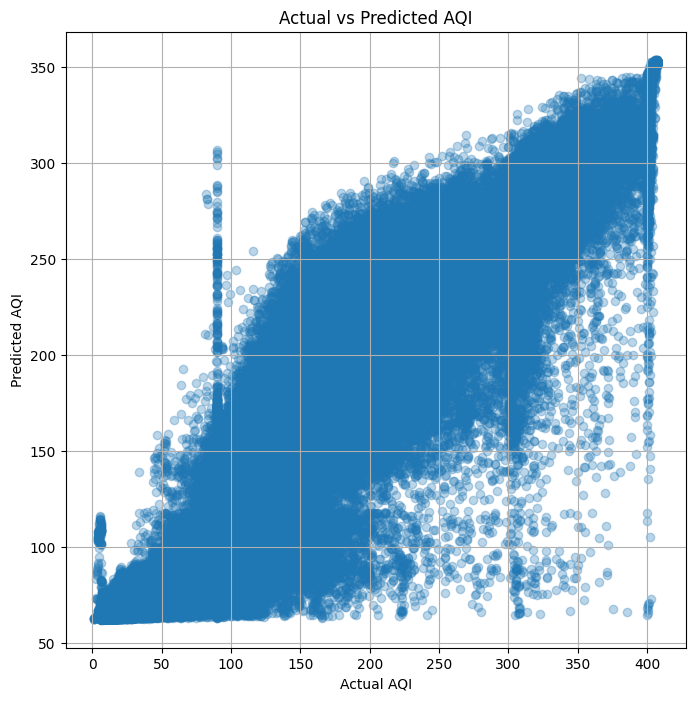

In [115]:
# ==========================================
# ACTUAL vs PREDICTED
# ==========================================

plt.figure(figsize=(8,8))

plt.scatter(
    actual_values,
    predictions,
    alpha=0.3
)

plt.xlabel("Actual AQI")

plt.ylabel("Predicted AQI")

plt.title("Actual vs Predicted AQI")

plt.grid(True)

plt.show()

In [116]:
# ==========================================
# SAVE ALL ARTIFACTS
# ==========================================

import joblib

joblib.dump(
    feature_scaler,
    os.path.join(
        PROJECT_DIR,
        "feature_scaler.pkl"
    )
)

joblib.dump(
    target_scaler,
    os.path.join(
        PROJECT_DIR,
        "target_scaler.pkl"
    )
)

joblib.dump(
    state_encoder,
    os.path.join(
        PROJECT_DIR,
        "state_encoder.pkl"
    )
)

joblib.dump(
    city_encoder,
    os.path.join(
        PROJECT_DIR,
        "city_encoder.pkl"
    )
)

joblib.dump(
    FEATURE_COLUMNS,
    os.path.join(
        PROJECT_DIR,
        "feature_columns.pkl"
    )
)

print("✅ All files saved successfully.")

✅ All files saved successfully.
